# Lesson 15: Characters vs word pieces: a fair comparison

**Why:** we now have two GPTs trained **exactly the same way** (same size, same 3,000 steps, same data, about 40 minutes each). The only difference is how they read text:

| | Character model (Lesson 12) | BPE model (this lesson) |
|---|---|---|
| one token = | 1 character | a word piece (2.2 characters on average) |
| vocabulary | 85 | 512 |
| 128 tokens of context = | 128 characters | about 280 characters |

**The trap:** their loss numbers **can't be compared directly**. Choosing 1 of 512 word pieces is a harder question than choosing 1 of 85 characters, but each answer covers more text. It's like comparing a price per item with a price per kilo.

**The fix: bits per character (BPC).** We count the model's total "surprise" over the **same validation text**, and divide by the number of **characters**, whichever way it was cut into tokens:

$$\text{BPC} = \frac{\text{total loss over the text}}{\text{number of characters} \times \ln 2}$$

(Dividing by ln 2 converts the loss into **bits**: roughly, how many yes/no questions the model needs per character. Lower is better.)

## 1. Load both models

In [1]:
import math
import re
import time
import torch
import matplotlib.pyplot as plt

from tinygpt.data import get_batch, load_text
from tinygpt.train import CHECKPOINT_DIR, load_model

text = load_text()
val_text = text[int(0.9 * len(text)):]       # the last 10%: neither model trained on it

models = {}
for name, file in [("character", "tesla_best.pt"), ("BPE", "tesla_bpe_best.pt")]:
    model, tok, ckpt = load_model(CHECKPOINT_DIR / file)
    models[name] = {"model": model, "tok": tok, "ckpt": ckpt}
    print(f"{name:10} vocab {model.config.vocab_size:4d} | {model.num_params():,} parameters | "
          f"val loss {ckpt['best_val']:.3f} per token | {ckpt['minutes']:.0f} min of training")

character  vocab   85 | 830,037 parameters | val loss 1.274 per token | 37 min of training
BPE        vocab  512 | 939,776 parameters | val loss 2.534 per token | 43 min of training


The BPE model has a few more parameters: its token table and output layer have 512 rows instead of 85. Its loss *per token* looks much **worse**. Now let's compare them fairly.

## 2. Bits per character

**Predict:** measured per character on the same text, which model will win: the **character** model, the **BPE** model, or a tie?

In [2]:
@torch.no_grad()
def bits_per_char(model, tok, text, batches=100):
    ids = torch.tensor(tok.encode(text))
    chars_per_token = len(text) / len(ids)
    torch.manual_seed(0)
    loss = sum(model(*get_batch(ids, 32, model.config.block_size))[1].item() for _ in range(batches)) / batches
    return loss / chars_per_token / math.log(2), chars_per_token

for name, m in models.items():
    m["bpc"], m["cpt"] = bits_per_char(m["model"], m["tok"], val_text)
    print(f"{name:10} {m['cpt']:.2f} characters per token  ->  {m['bpc']:.3f} bits per character")

character  1.00 characters per token  ->  1.837 bits per character


BPE        2.18 characters per token  ->  1.691 bits per character


## 3. Learning over time, on the fair scale

Both training histories converted to bits per character, plotted against **minutes of training** (what actually costs you).

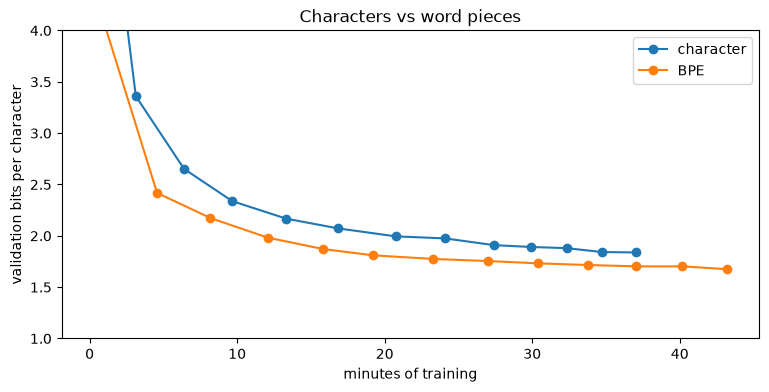

In [3]:
plt.figure(figsize=(9, 4))
for name, m in models.items():
    h = m["ckpt"]["history"]
    plt.plot([r["minutes"] for r in h], [r["val"] / m["cpt"] / math.log(2) for r in h], "o-", label=name)
plt.xlabel("minutes of training"); plt.ylabel("validation bits per character")
plt.ylim(1.0, 4.0); plt.legend(); plt.title("Characters vs word pieces"); plt.show()

## 4. Their writing, side by side

Same prompt, same temperature (0.8), same random seed, about 600 characters each. We also measure the share of **real words**: generated words that actually appear somewhere in Tesla's book.

In [4]:
book_words = set(re.findall(r"[a-z]+", text.lower()))
prompt = "The alternating current "

for name, m in models.items():
    tok, model = m["tok"], m["model"]
    n_tokens = round(600 / m["cpt"])                  # about 600 characters for both
    torch.manual_seed(42)
    start = time.time()
    out = tok.decode(model.generate(torch.tensor([tok.encode(prompt)]), n_tokens, temperature=0.8)[0].tolist())
    seconds = time.time() - start
    words = re.findall(r"[a-z]+", out.lower())
    m["real"] = sum(w in book_words for w in words) / len(words)
    print(f"===== {name} model: {m['real']:.0%} real words, written in {seconds:.1f}s =====")
    print(out)
    print()

===== character model: 96% real words, written in 7.2s =====
The alternating current sections as it may be
all of the streams of the between contact-rings seems in the case, as the
current of a this end is this apparatus in when a positials, of very reach
operate power the electrode, between, and the other are induced moidified
through the first of a coil are or thus secondary conductor alternating
currents of the latter ses and oll are atoms, y{2} F 10000 and are 20,02;
and to a secondary circuit is shown to D, that of the coil is a very
different perform of
the few the resistance with effect; the secondary excite change of the
coils of when pole, as a but the previous are ad



===== BPE model: 95% real words, written in 3.2s =====
The alternating current impulse, even off a
degree of insulating liquid, was sufficient to suit the surface of the space. This
evidently against the gas in this result case, incans
and the machine would be very high, the latter should be remersed. If a very small charged,
but a progressively given if the potential be factly them and more or small
air, if the loss at first, the thin points on
the other incandescence and electrical cause. This result is, of
evoidsing a directly, that great resultant.

A successively feeble works which is impropell directly again dependent on the points of
the employment of the conduct



## 5. The whole course on one scale

In [5]:
LN2 = math.log(2)
journey = [
    ("know nothing (Lesson 3)", 4.443 / LN2),
    ("character frequencies (Lesson 4)", 3.046 / LN2),
    ("bigram (Lesson 6)", 2.406 / LN2),
    ("one attention head (Lesson 8)", 2.31 / LN2),
    ("4 heads + feed-forward (Lesson 9)", 1.90 / LN2),
    ("first GPT, 6.5 min (Lesson 10)", 1.51 / LN2),
    ("character GPT, 37 min (Lesson 12)", models["character"]["bpc"]),
    ("BPE GPT, same budget (Lesson 15)", models["BPE"]["bpc"]),
]
for name, bpc in journey:
    print(f"{name:36} {bpc:5.2f} bits/char  " + "#" * round(bpc * 8))

know nothing (Lesson 3)               6.41 bits/char  ###################################################
character frequencies (Lesson 4)      4.39 bits/char  ###################################
bigram (Lesson 6)                     3.47 bits/char  ############################
one attention head (Lesson 8)         3.33 bits/char  ###########################
4 heads + feed-forward (Lesson 9)     2.74 bits/char  ######################
first GPT, 6.5 min (Lesson 10)        2.18 bits/char  #################
character GPT, 37 min (Lesson 12)     1.84 bits/char  ###############
BPE GPT, same budget (Lesson 15)      1.69 bits/char  ##############


## 6. Final check

In [6]:
assert all(0.5 < m["bpc"] < 3 for m in models.values())
print("Lesson 15 complete.")

Lesson 15 complete.


## Wrap-up question

Which tokenizer would you pick for the final Tesla model, and why? Think about the score, the quality of the writing, speed, and what each one can handle (remember ć).